# BIS API exploration

Probe the BIS MCP tools. The MCP server must be running (`python mcp_server/server.py`).

BIS needs no credentials. A dataflow (e.g. `WS_CBPOL`) is the dataset; its data
structure (often the same id with `WS_` → `BIS_`, e.g. `BIS_CBPOL`) declares the
dimensions and the codelists that decode them.

In [9]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from matplotlib import pyplot
from lib import config
from lib.utils import print_json_vertical
from utils import (
    call_tool,
    list_mcp_tools,
    show_dataflows,
    show_datastructure,
    get_series,
    decode_series,
    plot_bis_series,
)

pyplot.style.use(config.glyfish_style)

## Available tools

In [2]:
await list_mcp_tools()

fred_category_children: List the child categories for a FRED category.
fred_category_series: List the series contained within a FRED category.
fred_series_info: Fetch metadata for a single FRED series.
fred_series_observations: Return observations for a series (limit defaults to 100).
fred_series_updates: Return recently updated FRED series.
list_releases: List the series that belong to a FRED release.
fred_release_series: List the series that belong to a FRED release.
tiingo_series_info: Fetch metadata for a Tiingo ticker (ETF, mutual fund, or stock), including its available date range.
tiingo_price_series: Return the end-of-day price series (OHLCV plus split/dividend-adjusted prices) for a Tiingo ticker. Provide start_date/end_date as YYYY-MM-DD for a range; omit for the latest day.
bls_series_data: Fetch observations for one or more BLS series IDs (up to 50). Optionally restrict to a start_year/end_year range and enable catalog metadata, net/percent-change calculations, annual avera

## Dataflows

The 29 published datasets — credit, policy rates, property prices, banking, etc.

In [3]:
flows = await show_dataflows()

BIS_REL_CAL            BIS_RELEASE_CALENDAR
WS_CBPOL               Central bank policy rates
WS_CBS_PUB             Consolidated banking
WS_CBTA                Central bank total assets
WS_CPMI_CASHLESS       CPMI cashless payments
WS_CPMI_CT1            CPMI comparative tables type 1
WS_CPMI_CT2            CPMI comparative tables type 2
WS_CPMI_DEVICES        CPMI payment devices
WS_CPMI_INSTITUT       CPMI institutions
WS_CPMI_MACRO          CPMI macro
WS_CPMI_PARTICIP       CPMI participants
WS_CPMI_SYSTEMS        CPMI systems
WS_CPP                 Commercial property prices
WS_CREDIT_GAP          Credit-to-GDP gaps
WS_DEBT_SEC2_PUB       International debt securities (BIS-compiled)
WS_DER_OTC_TOV         OTC derivatives turnover
WS_DPP                 Detailed residential property prices
WS_DSR                 Debt service ratios
WS_EER                 Effective exchange rates
WS_GLI                 Global liquidity indicators
WS_LBS_D_PUB           Locational banking
WS_LONG_CPI 

## Data structure

The dimensions that make up a series key, and the codelist decoding each.
Codelists are summarized by count (some hold 1000+ codes).

In [4]:
dsd = await show_datastructure("BIS_TOTAL_CREDIT")

BIS_TOTAL_CREDIT: BIS long series on total credit
dimensions (key order): ['FREQ', 'BORROWERS_CTY', 'TC_BORROWERS', 'TC_LENDERS', 'VALUATION', 'UNIT_TYPE', 'TC_ADJUST']
  CL_ADJUST              4 codes
  CL_AREA                101 codes
  CL_BIS_UNIT            1096 codes
  CL_COLLECTION          10 codes
  CL_CONF_STATUS         5 codes
  CL_DECIMALS            17 codes
  CL_FREQ                8 codes
  CL_OBS_STATUS          16 codes
  CL_TC_BORROWERS        5 codes
  CL_TC_LENDERS          2 codes
  CL_UNIT_MULT           11 codes
  CL_VALUATION           2 codes


## Fetch and decode a series

Central bank policy rates for the US, UK, Japan and the euro area. `decode_series`
labels the dimension codes (`REF_AREA=US` → `United States`).

In [10]:
data = await decode_series("WS_CBPOL", "M.US+GB+JP+XM", "BIS_CBPOL", start_period="2015-01")
for s in data["series"]:
    print(s["key"], "->", s["labels"])

M.GB.368 -> {'FREQ': 'Monthly', 'REF_AREA': 'United Kingdom'}
M.JP.368 -> {'FREQ': 'Monthly', 'REF_AREA': 'Japan'}
M.US.368 -> {'FREQ': 'Monthly', 'REF_AREA': 'United States'}
M.XM.368 -> {'FREQ': 'Monthly', 'REF_AREA': 'Euro area'}


## Plot a series

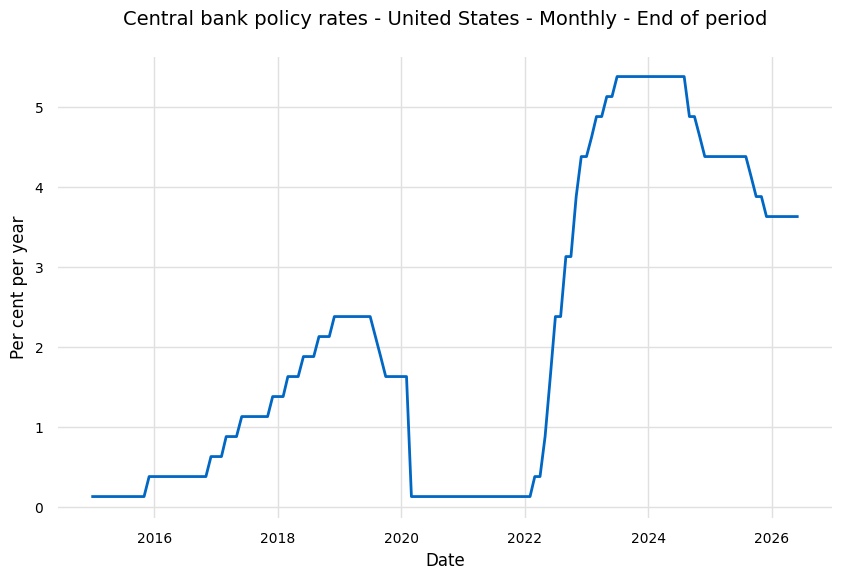

In [11]:
us = next(s for s in data["series"] if s["dimensions"].get("REF_AREA") == "US")
plot_bis_series(us)

## Series keys

`key` is the dot-joined dimension values in DSD order. Omit a position to
wildcard it, use `+` for alternatives, or `all` for every series. Inspect the
data structure first to know the dimension order and valid codes.

In [12]:
# every series in a flow (careful: large flows return a lot)
# data = await get_series("WS_CBPOL", "all", start_period="2026-01")
credit = await show_datastructure("BIS_TOTAL_CREDIT")

BIS_TOTAL_CREDIT: BIS long series on total credit
dimensions (key order): ['FREQ', 'BORROWERS_CTY', 'TC_BORROWERS', 'TC_LENDERS', 'VALUATION', 'UNIT_TYPE', 'TC_ADJUST']
  CL_ADJUST              4 codes
  CL_AREA                101 codes
  CL_BIS_UNIT            1096 codes
  CL_COLLECTION          10 codes
  CL_CONF_STATUS         5 codes
  CL_DECIMALS            17 codes
  CL_FREQ                8 codes
  CL_OBS_STATUS          16 codes
  CL_TC_BORROWERS        5 codes
  CL_TC_LENDERS          2 codes
  CL_UNIT_MULT           11 codes
  CL_VALUATION           2 codes
